<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
Hierarchical Clustering
</h1>

# 🎬 Clustering Movies with Agglomerative Clustering

This analysis uses the **Agglomerative Clustering** algorithm to uncover natural groupings in movie data from the TMDb dataset.   
Hierarchical clustering builds a **tree-like structure (dendrogram)** that reveals how movies merge into clusters at various levels of similarity, without requiring a predefined number of clusters.

## 🎯 Objective

The goal is to explore the underlying structure of the movie landscape — from cult classics to blockbuster hits — using a **bottom-up hierarchical approach**.  
This method allows us to identify both fine-grained and high-level clusters in a purely data-driven, unsupervised manner.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA

import plotly.express as px

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import plotly.graph_objects as go

import warnings
warnings.simplefilter(action='ignore')

In [99]:
data = pd.read_csv('tmdb_movies_cleaned.csv')

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [101]:
data.columns

Index(['id', 'title', 'runtime', 'release_date', 'budget', 'revenue',
       'popularity', 'vote_average', 'vote_count', 'belongs_to_collection',
       'has_tagline', 'has_homepage', 'num_same_title', 'changed_title',
       'num_genres', 'Comedy', 'Action', 'Animation', 'Drama', 'History',
       'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy',
       'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance',
       'Mystery', 'Horror', 'top10_prod_comps', 'num_production_companies',
       'main_production_country', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'season',
       'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

## 🔍 Feature Selection

- Hierarchical clustering is highly dependant on distance calculations.  
- This makes Hierarchical clustering sensitive to **outliers** and **scale differences**.
- Irrelevant or noisy features can confuse the algorithm and produce meaningless clusters.
___

In [102]:
data['belongs_to_collection'] = data['belongs_to_collection'].astype(bool)
data['has_tagline'] = data['has_tagline'].astype(bool)
data['has_homepage'] = data['has_homepage'].astype(bool)

In [103]:
data = data.drop('id', axis=1)

In [104]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])
numeric_data.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'num_same_title', 'num_genres',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'popularity_percentile', 'weighted_rating',
       'release_year', 'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

## 📁 Organizing Relevant Data
#### 1. **🟣 Log Transformation for Skewed Features:**
   - Features like `budget`, `revenue`, and `vote_count` are often right-skewed (long tail).
   - Fix: Log transformation reduces the influence of extreme values and improves clustering.

##### When to Apply Log Transformation?
- Only when values are **positive**.
- When the distribution is **right-skewed** (long tail to the right).
- To **reduce the impact of outliers**.
- Helps to **compress extreme values** and make the distribution more balanced.


#### 2. **🧹 Outlier Removal:**
   - Agglomerative Hierarchical Clustering is sensitive to outliers, as it relies heavily on pairwise distances between points.  
   - Fix: To improve clustering quality and interpretability, we will apply outlier removal before clustering.

##### **IQR** (Interquartile Range) Method: Detects outliers based on statistical spread between quartiles.
- There are ofcourse more methods of outlier removal, however we have decided to continue with the IQR method.  
- This is because IQR is more robust for skewed or non-normal distributions, which is common in most of our features.


#### 3. **🔧 Scaling Features:**
   - Distance-based algorithms, such as Agglomerative Clustering, are sensitive to feature scale.
   - Fix: Apply standardization (mean = 0, std = 1) to ensure fair contribution of all features.

##### When to Apply Feature Scaling?
- When using algorithms that rely on **Euclidean distances**.
- When features have **different units or magnitudes** (e.g., `runtime` vs. `popularity`).
- To prevent **domination of large-scale features** in clustering results.
___

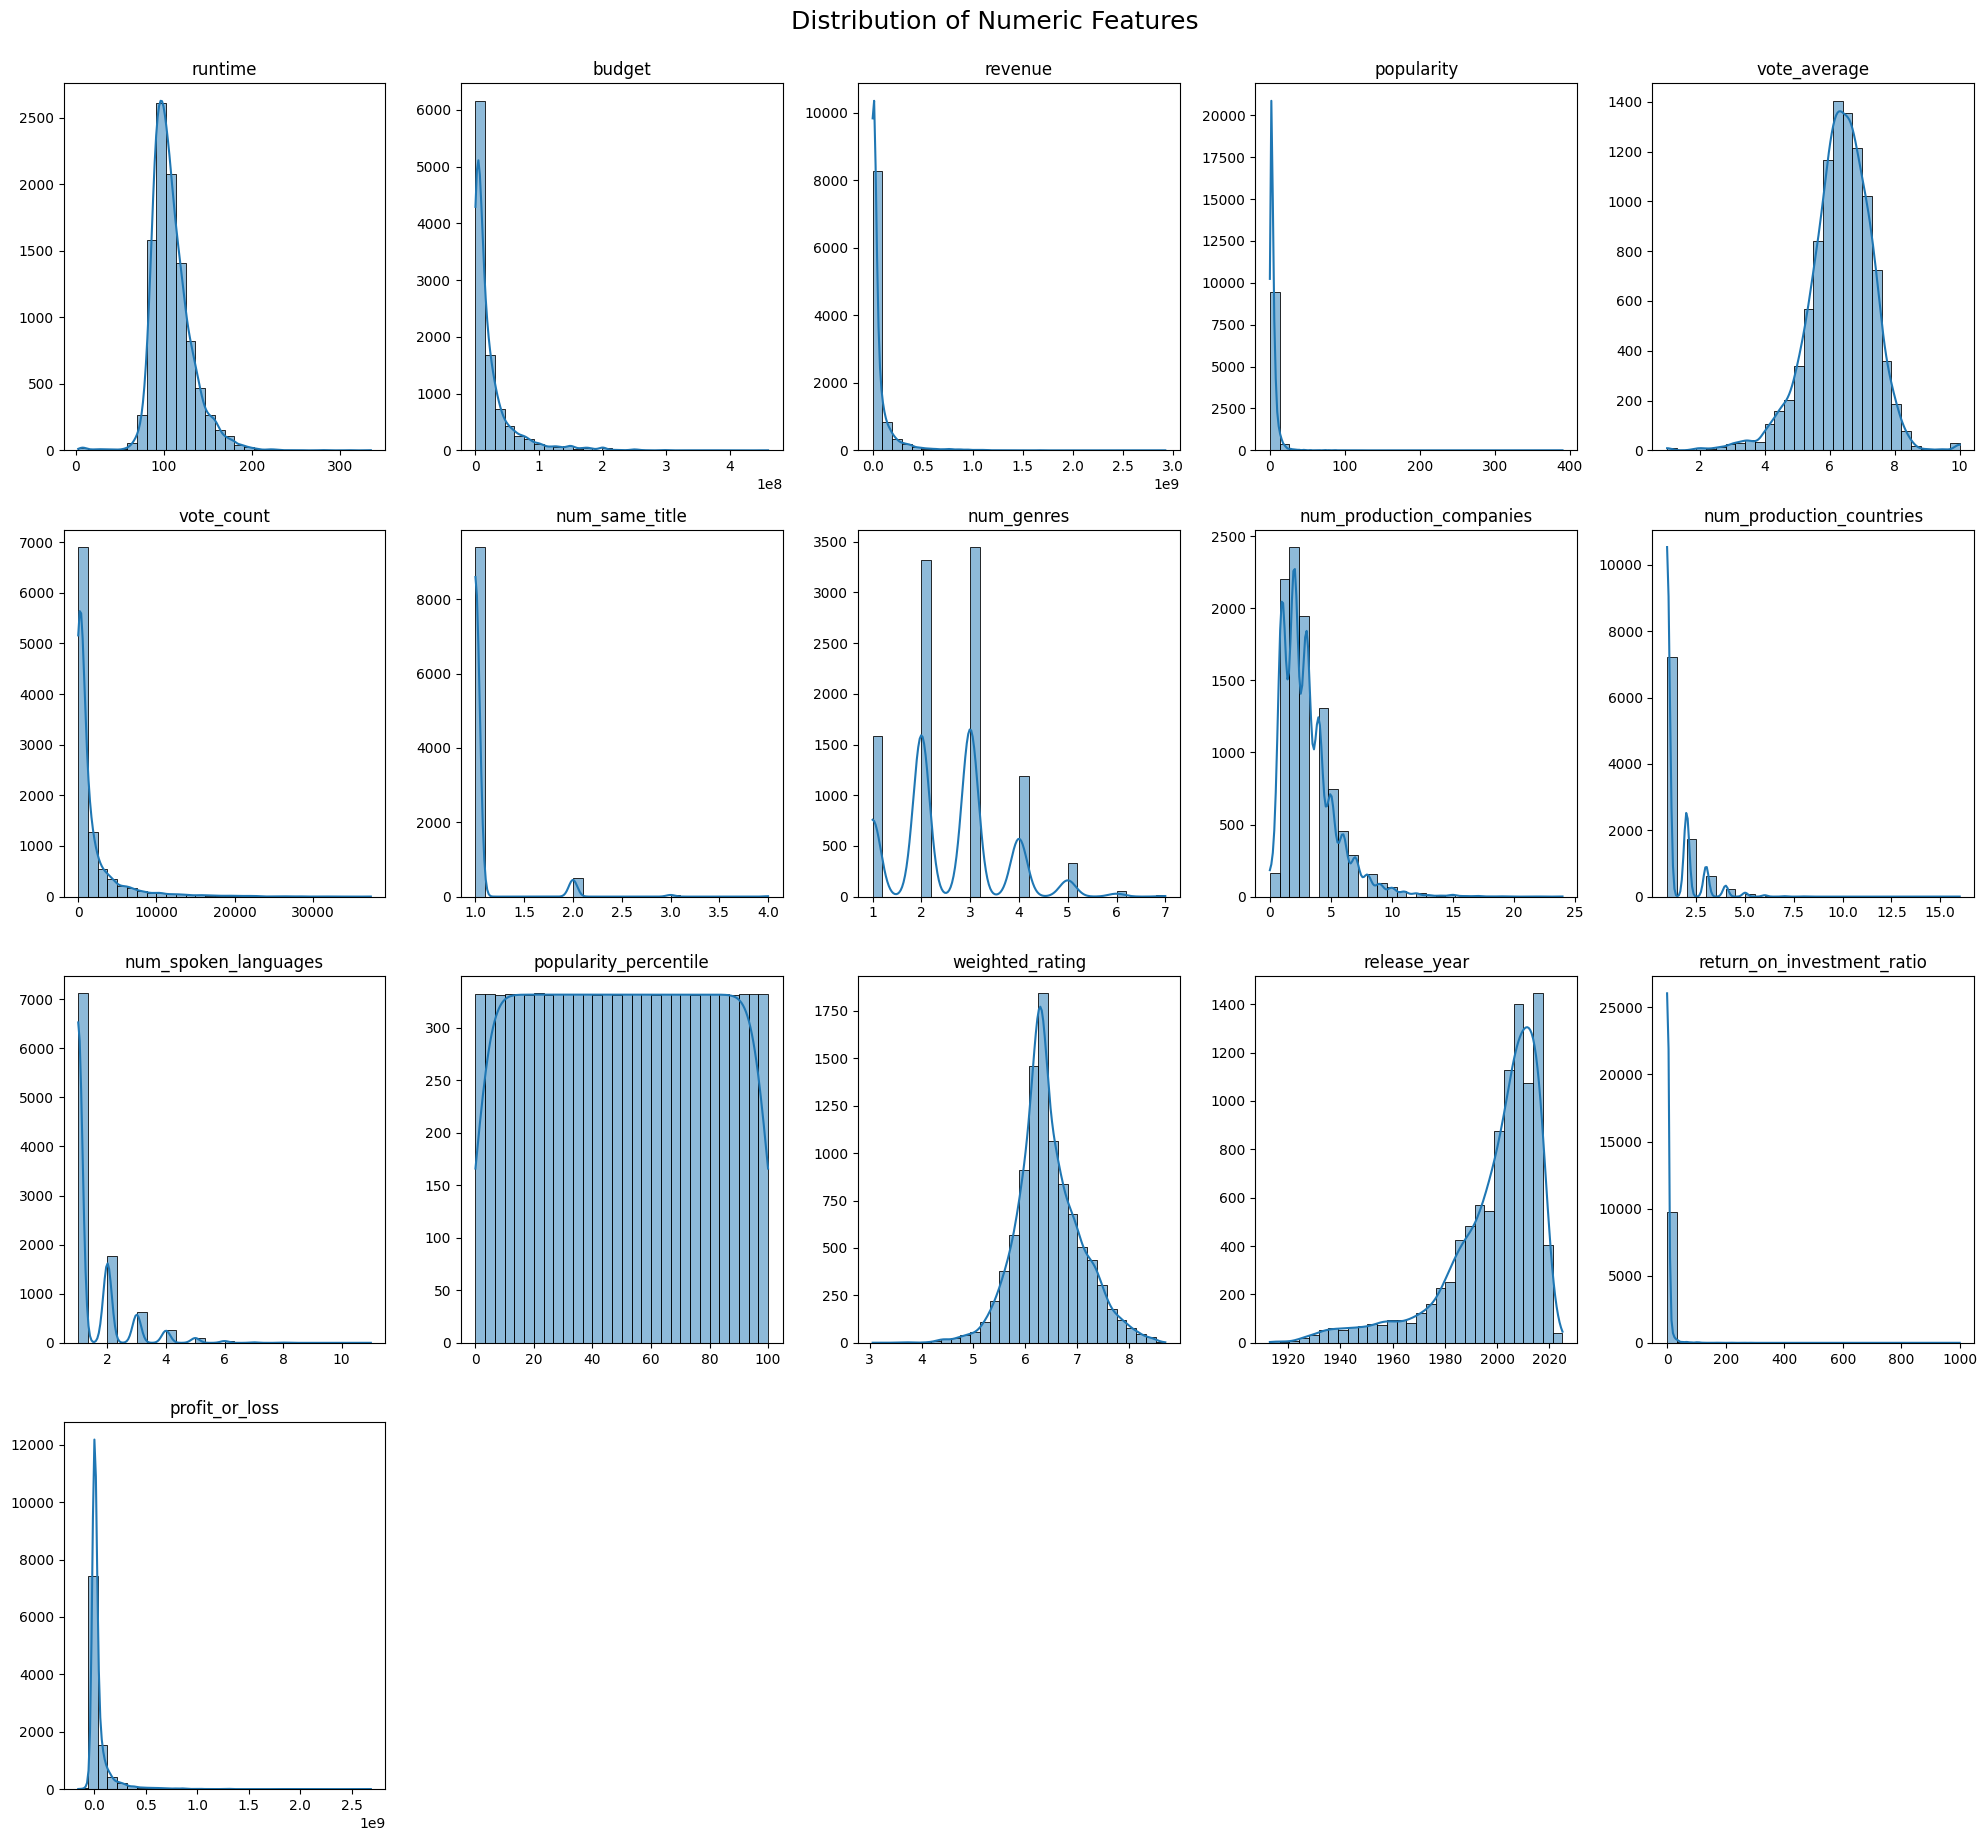

In [105]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(numeric_data):
    plt.subplot(4, 5, i+1)
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.suptitle('Distribution of Numeric Features', fontsize=18, y=1.02)
plt.show()

**Recommended columns for Log transformation**:  
`budget`, `revenue`, `popularity`, `vote_count`, `return_on_investment_ratio`, `profit_or_loss`


In [106]:
log_features = [
    'budget',
    'revenue',
    'popularity',
    'vote_count',
    'return_on_investment_ratio',
    'profit_or_loss'
]

In [107]:
# Regular – no negative values
data['budget'] = np.log1p(data['budget'])
data['revenue'] = np.log1p(data['revenue'])
data['popularity'] = np.log1p(data['popularity'])
data['vote_count'] = np.log1p(data['vote_count'])

# Contains negative values – apply shift to ensure positivity
data['return_on_investment_ratio'] = np.log1p(data['return_on_investment_ratio'] - data['return_on_investment_ratio'].min() + 1)
data['profit_or_loss'] = np.log1p(data['profit_or_loss'] - data['profit_or_loss'].min() + 1)

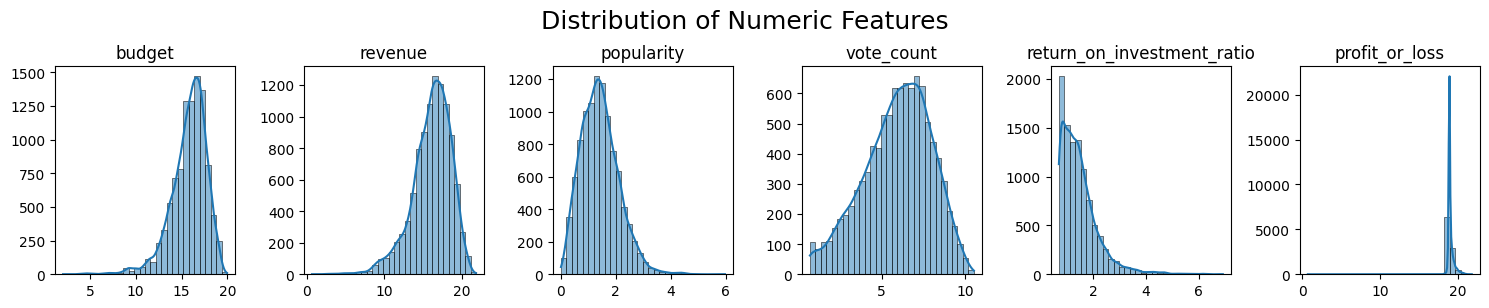

In [108]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(log_features):
    plt.subplot(4, 6, i+1)
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.suptitle('Distribution of Numeric Features', fontsize=18, y=1.02)
plt.show()

In [109]:
# IQR Function (Removes rows where any feature lies outside the IQR range)

def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

___
## ⚙️ Question Ensembling
In this notebook we have decided to pre-determine research questions that align with the algorithms unique strengths.  
Given the full set of available features, we selected specific analytical questions tailored to the strengths of the hierarchical clustering algorithm.  
Each question was carefully crafted to highlight the algorithm’s ability to uncover **nested structures** and work effectively with **various distance metrics**.

By designing each question around a targeted set of features, we aimed to thoroughly assess clustering performance and demonstrate how hierarchical clustering can reveal meaningful patterns and structure in the data.

### 🎯 Our Three Guiding Questions:

1. **Release Year Patterns**  
   → Can movies be grouped by their release year without explicitly using the year?

2. **Potential Success Patterns**  
   → Can we identify groups of movies with different potential success levels using only features available before release?

3. **Structural Production Patterns**  
   → Can we identify meaningful clusters of movies based on structural production features?

___

## 📅 Question 1: Release Year Patterns

**❓ Question:**  
Can movies be grouped by their release year without explicitly using the year?

 🔍 **What We Check:**
- Use only features that we assume naturally change over time:
  - **Budget**
  - **Runtime**
  - **Revenue**
- Do **not** include the release year itself as a feature.
- Evaluate if the algorithm can implicitly identify natural groupings based on the period when the movies were released (e.g., movies released before 2000 vs newer movies).

 🎯 **What We Expect to See:**
- Clearly separated groups corresponding to different release periods, indicating that these features effectively reflect temporal trends.

 ✅ **Advantage:**
- Tests the algorithm's ability to uncover hidden temporal patterns without directly relying on the release year.

In [110]:
data_q1 = data.copy()

# Features for clustering
features_q1 = ['budget', 'runtime', 'revenue']

# Keep 'release_year' for later 
df_q1 = data_q1[features_q1 + ['release_year']].dropna(subset=features_q1 + ['release_year']).copy()

In [111]:
# Outlier removal
before_count = len(df_q1)

data_filtered = remove_outliers_iqr(data_q1, features_q1)

print(f"Rows before outlier removal: {before_count}")
print(f"Rows after outlier removal: {len(data_filtered)}")

Rows before outlier removal: 9953
Rows after outlier removal: 9166


In [112]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features_q1])

---

### 🔗 Trying Different Linkage Methods

We tested four linkage methods to compare how each one affects the structure of hierarchical clustering and the resulting clusters.  
For each method, we print both a **dendrogram** (to visualize the merging structure) and a **scatter plot** (based on PCA) showing the resulting clusters in 2D space.

Note: After manualy running the dendrograms first, we then defined number of clusters at 3 - seemed to be the most equal for all (just for general comparison between the methods) 

By comparing these visualizations, we aim to identify which method produces the **clearest**, **most distinct**, and **interpretable** cluster separation.

#### Methods:
- **Ward** – minimizes variance within clusters; creates compact groups.
- **Complete** – merges based on the **farthest** pair; sensitive to outliers.
- **Average** – merges based on the **average** distance; a balanced approach.
- **Single** – merges based on the **closest** pair; may cause chaining.

---


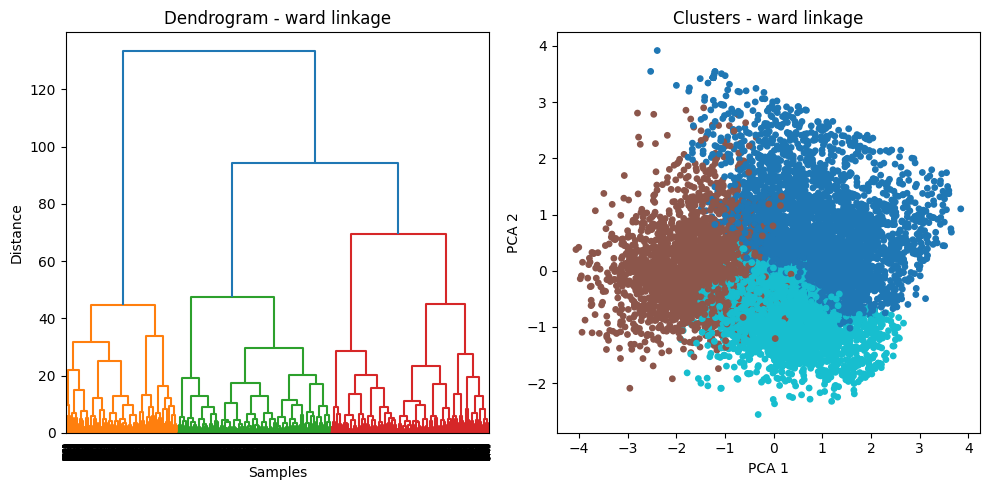

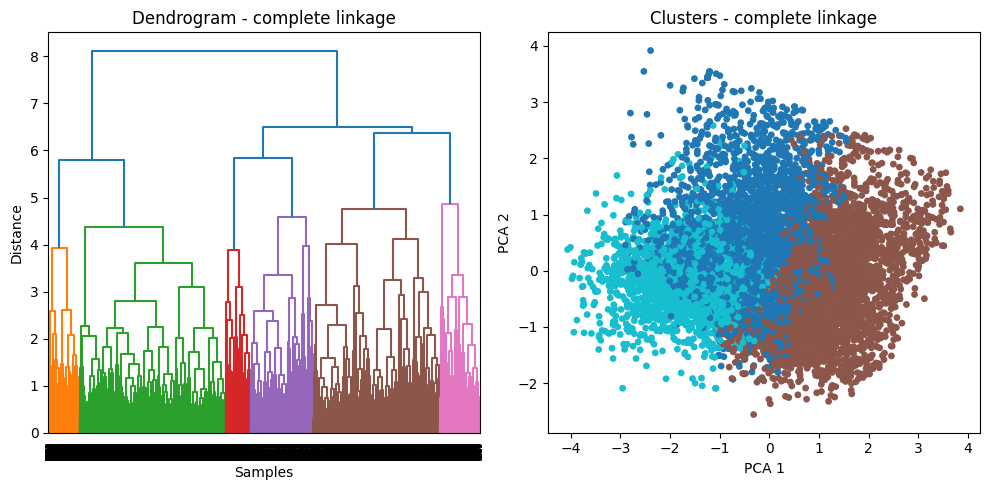

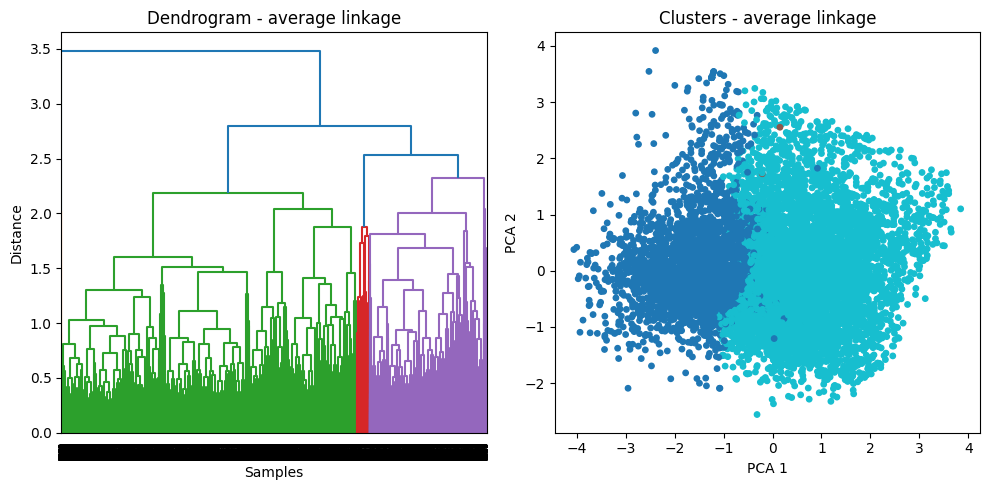

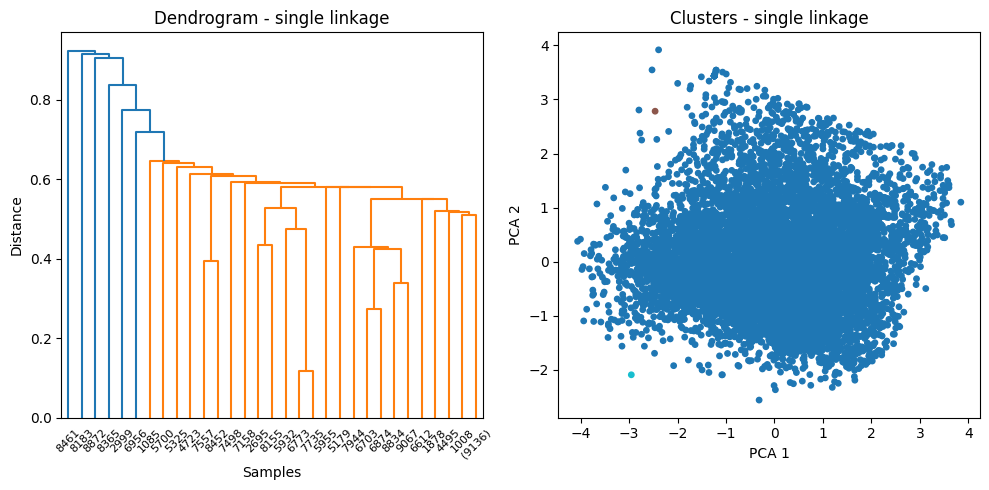

In [113]:
# List of linkage methods to test
linkage_methods = ['ward', 'complete', 'average', 'single']

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


for method in linkage_methods:
    linked = linkage(X_scaled, method=method)

    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    clusters = model.fit_predict(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Subplot 1: Dendrogram
    dendrogram(linked, truncate_mode='level', p=20, ax=axes[0])
    axes[0].set_title(f'Dendrogram - {method} linkage')
    axes[0].set_xlabel('Samples')
    axes[0].set_ylabel('Distance')

    # Subplot 2: Cluster visualization using PCA
    scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=15)
    axes[1].set_title(f'Clusters - {method} linkage')
    axes[1].set_xlabel('PCA 1')
    axes[1].set_ylabel('PCA 2')

    plt.tight_layout()
    plt.show()


### ✅ Conclusion: Choosing the Best Linkage Method

After comparing both the **dendrograms** and **PCA-based scatter plots** for each linkage method, we observed clear differences in cluster quality and structure:

- **Ward**:  
  🔹 *Dendrogram*: Displays a clear hierarchical structure with large, well-defined merges at the top.  
  🔹 *Scatter plot*: Shows three **well-separated and compact clusters** — the cleanest result.

- **Complete**:  
  🔹 *Dendrogram*: Reasonably balanced merges, though less clear than Ward.  
  🔹 *Scatter plot*: Clusters are distinguishable but **less compact** than with Ward.

- **Average**:  
  🔹 *Dendrogram*: Merges happen gradually with **no clear jump** between clusters.  
  🔹 *Scatter plot*: Clusters appear **blurry and overlapping**, harder to interpret.

- **Single**:  
  🔹 *Dendrogram*: Shows the **chaining effect** (clusters merge one by one with minimal distance).  
  🔹 *Scatter plot*: Results in **one dominant cluster** and fails to separate the data meaningfully.

🔎 **Conclusion**:  
We selected **Ward linkage** as the most effective method, as it produces the **clearest separation**, **most compact clusters**, and **interpretable hierarchical structure** in both visualizations.

---


### 🔢 Trying Different Values of `n_clusters`

In hierarchical clustering, the algorithm builds a full tree of nested merges, but we still need to **decide where to "cut" the dendrogram** — i.e., how many clusters to extract (`n_clusters`).

To explore the best cut point, we apply a **trial-and-error approach**:  
We visualize the clustering results for different values of `n_clusters` using PCA-reduced data.

#### Why it's important:
- In **hierarchical clustering**, choosing the number of clusters affects not just the results — but also how well we preserve the **structure of the hierarchy**.
- Too few clusters may oversimplify the data, while too many may break apart meaningful groups.

📊 Below, we compare clustering results for `n_clusters = 2, 3, 4, 5` using **Ward linkage**, and analyze which value provides the clearest and most meaningful separation.



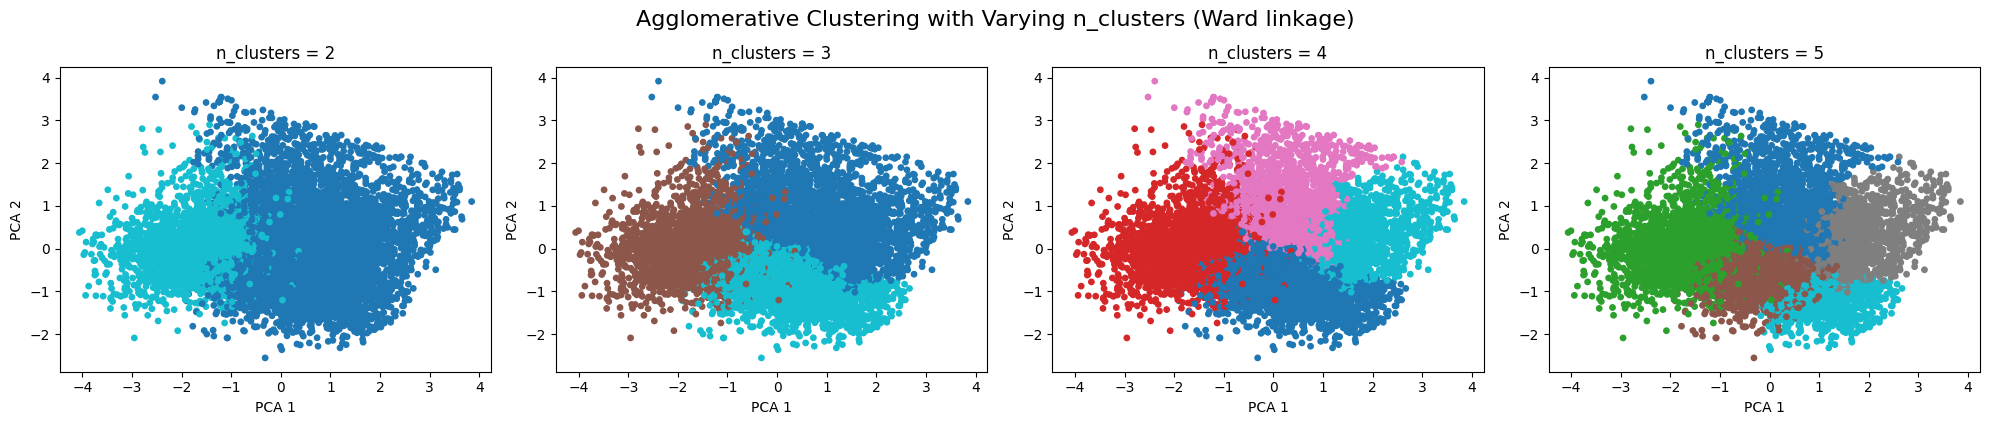

In [114]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# List of cluster counts (K values) to test
cluster_counts = [2, 3, 4, 5]

plt.figure(figsize=(20, 4))

for i, k in enumerate(cluster_counts):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    clusters = model.fit_predict(X_scaled)

    plt.subplot(1, len(cluster_counts), i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=15)
    plt.title(f'n_clusters = {k}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')

plt.tight_layout()
plt.suptitle('Agglomerative Clustering with Varying n_clusters (Ward linkage)', fontsize=16, y=1.05)
plt.show()



### ✅ Conclusion: Selecting the Optimal Number of Clusters

We compared the clustering results for `n_clusters = 2, 3, 4, 5` using Ward linkage, based on the 2D PCA projection.

- With **2 clusters**, the data is split broadly, but potentially hides finer structure.
- **3 clusters** introduces a clear third group and offers good separation with minimal overlap.
- **4 clusters** shows further division, but some boundaries begin to blur.
- With **5 clusters**, the groups appear increasingly fragmented and overlapping, reducing interpretability.

🔎 **Conclusion**:  
We selected **3 clusters** as the most balanced choice — it reveals meaningful structure while maintaining clear separation and simplicity.

---


## ▶️ Continuing with the Best Configuration

After testing multiple **linkage methods** and experimenting with different values of `n_clusters`,  
we decided to proceed with the **Ward linkage** method and **3 clusters**, as this combination provided the clearest and most meaningful clustering results.

From this point on, all further analysis will be based on this optimal configuration.


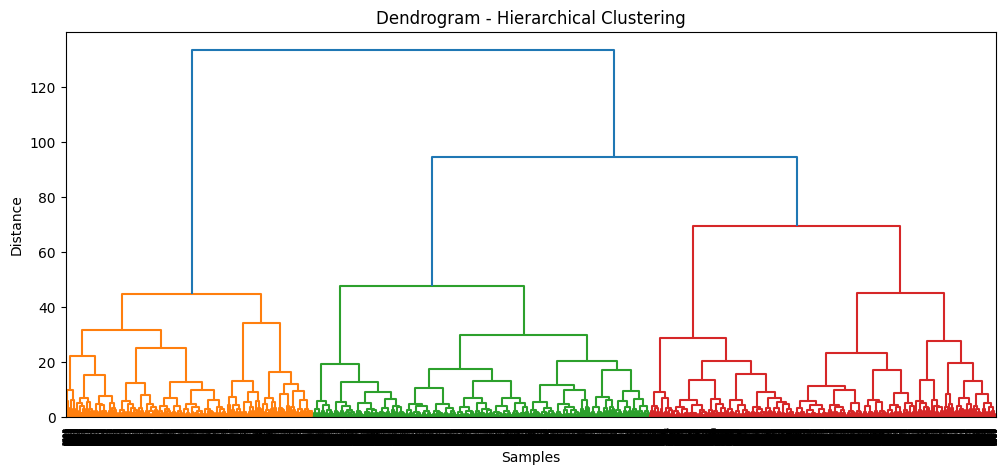

In [115]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [116]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = model.fit_predict(X_scaled)

In [117]:
# Adding the clusters to the data
data_filtered_with_clusters1 = data_filtered.copy()
data_filtered_with_clusters1['cluster'] = clusters

In [118]:
# 3D visualization - Budget and Revenue Log Transformed !
fig = px.scatter_3d(
    data_filtered_with_clusters1,
    x='budget',
    y='runtime',
    z='revenue',
    color='cluster',
    hover_data=['release_year']
)

fig.update_layout(title='3D Clustering by Budget (Log), Runtime and Revenue (Log)')
fig.show()

In [119]:
# Removing the Log transformation (after clustering already performed) - for better visualization and later for interpretation
data_filtered_with_clusters1['budget'] = np.expm1(data_filtered_with_clusters1['budget'])
data_filtered_with_clusters1['revenue'] = np.expm1(data_filtered_with_clusters1['revenue'])

In [120]:
# 3D visualization - Original Values !
fig = px.scatter_3d(
    data_filtered_with_clusters1,
    x='budget',
    y='runtime',
    z='revenue',
    color='cluster',
    hover_data=['release_year']
)

fig.update_layout(title='3D Clustering by Budget, Runtime and Revenue (Original Values)')
fig.show()

### 🎯 Insights from the 3D Scatter Plot (Hierarchical Clustering)

Visualizing clusters in 3D allows us to better understand the **spatial separation** and **structure** of the data across three original features — in this case:  
**`budget`**, **`runtime`**, and **`revenue`**.

#### 🧠 Key observations:
- **Distinct cluster regions**:  
  The colored clusters are relatively separated in space, suggesting that hierarchical clustering with Ward linkage captured meaningful groupings.

- **Elongated structure**:  
  The clusters appear **stretched along one axis** (likely `runtime`), indicating that this feature may be a stronger driver in the clustering.

- **Overlaps and depth**:  
  Some overlap exists when viewing from certain angles — the 3D view helps reveal **depth and hidden separations** not visible in 2D.

#### 🔗 Why this matters in hierarchical clustering:
- Unlike flat clustering (e.g., K-means), hierarchical clustering **does not assume spherical clusters**.  
  The 3D plot confirms that clusters are **not perfectly round** and may vary in shape, size, and orientation — which fits well with the hierarchical approach.

---


### 🔍 Next Step: Cluster Interpretation

Now that we have obtained our final clustering results, the next step is to **analyze the characteristics of each cluster**.

We'll explore whether these groupings reveal any **general patterns** in the data and whether they provide meaningful insights regarding our specific question about **release year patterns**.

The goal is to understand what each cluster represents — and whether this unsupervised grouping leads to useful observations.

In [121]:
stats = data_filtered_with_clusters1.groupby('cluster')['release_year'].agg(
    mean_release_year='mean',
    median_release_year='median',
    min_release_year='min',
    max_release_year='max',
    count='count'
).round(0)

print("📊 Release year statistics per cluster:\n")
stats


📊 Release year statistics per cluster:



,mean_release_year,median_release_year,min_release_year,max_release_year,count
cluster,,,,,
0,"2,001.00","2,006.00",1924,2025,3408
1,"1,992.00","2,003.00",1916,2025,2444
2,"2,001.00","2,004.00",1931,2024,3314


### 📉 Conclusion: No Clear Temporal Patterns in Clusters

Although `release_year` was not used in the clustering process, we checked whether the resulting clusters align with time periods.

- All clusters span a **wide and overlapping range of years**.
- Mean and median release years are **very close** (mostly ~1998–2000).
- No cluster clearly represents a specific era (e.g., pre/post-2000).

🔎 **Interpretation**:  
Clustering based on `budget`, `runtime`, and `revenue` did **not reveal meaningful chronological separation**.  
Temporal trends, if they exist, are too weak or diffuse to emerge from these features alone.

👉 **Next**, we will examine whether the clusters show clear and meaningful separation based on the other features, regardless of release year.

In [122]:
cluster_stats = data_filtered_with_clusters1.groupby('cluster').agg({
    'budget': ['mean', 'median', 'min', 'max'],
    'revenue': ['mean', 'median', 'min', 'max'],
    'runtime': ['mean', 'median', 'min', 'max']
}).round(1)

pd.set_option('display.float_format', '{:,.2f}'.format)

print("📊 Cluster-wise statistics (based on original values):\n")
cluster_stats

📊 Cluster-wise statistics (based on original values):



budget                                                revenue  \
                 mean        median        min            max           mean   
cluster                                                                        
0       36,947,843.40 20,000,000.00 100,000.00 416,000,000.00 108,922,311.30   
1        4,416,045.50  1,800,000.00  88,000.00 100,000,000.00   2,844,156.20   
2       25,407,019.10 15,000,000.00 500,000.00 260,000,000.00  69,258,340.50   

                                                    runtime                   
               median          min              max    mean median  min  max  
cluster                                                                       
0       39,135,565.00   100,000.00 2,068,223,624.00  124.70 122.00  100  159  
1        1,250,000.00    27,741.00   225,253,184.00   98.50  97.00   55  150  
2       26,177,890.50 2,091,037.00 1,453,683,476.00   96.00  96.00   63  115

### 📊 Cluster Interpretation Based on Original Feature Values

After performing hierarchical clustering on the features `budget`, `revenue`, and `runtime`,  
we analyzed the characteristics of each cluster using the **original, unnormalized values**.

#### 🔍 Observations:

- **Cluster 0**  
  • Very high **budget** and **revenue** on average.  
  • Contains the **highest max values** across all three features.  
  → Likely represents **big-budget blockbusters** or high-grossing commercial films.

- **Cluster 1**  
  • Lowest **budget**, **revenue**, and **runtime**.  
  • Represents **low-budget or independent productions**, possibly with limited releases.

- **Cluster 2**  
  • Moderate **budget** and **revenue**, with slightly lower runtime.  
  • Likely corresponds to **mid-scale, mainstream films**.

#### 🧠 Interpretation:

The clustering clearly separates films based on **commercial scale and investment level**:  
From low-budget productions to mid-level films and large-scale blockbusters.  
This insight was obtained **without using genre, popularity or ratings**,  
demonstrating the effectiveness of clustering on purely numerical financial features.
___

## 🎯 Question 2: Potential Success Patterns

**❓ Question:**  
Can we identify groups of movies with different potential success levels —  using only early features available before release.

🔍 **What We Check:**  
- After forming clusters based on early features, we will evaluate whether these groups differ in terms of actual success metrics such as: 
   - `popularity`
   - `return_on_investment_ratio`
- This helps us understand if early information can predict different success trajectories.


💡 **Why Hierarchical Clustering?**  
- Hierarchical clustering allows us to explore whether natural groups exist based on early production features such as:
   - `budget`
   - `runtime`
   - `release_year`
   - `num_genres`
- Since we do not know in advance how many distinct success profiles there are, this method lets us examine the full hierarchical structure  
and uncover meaningful groupings without predefining the number of clusters.

In [123]:
data_q2 = data.copy()

# Features for clustering
features_q2 = ['budget', 'num_genres', 'num_production_companies', 'release_year']

# Keep 'popularity' and 'return_on_investment_ratio' for later analysis
df_q2 = data_q2[features_q2 + ['popularity', 'return_on_investment_ratio']].dropna(subset=features_q2).copy()

In [124]:
before_count = len(df_q2)

data_filtered = remove_outliers_iqr(data_q2, features_q2)

print(f"Rows before outlier removal: {before_count}")
print(f"Rows after outlier removal: {len(data_filtered)}")

Rows before outlier removal: 9953
Rows after outlier removal: 8341


In [125]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features_q2])

### This time we will go with the **rule of thumb: 👍**
- Look for the largest vertical distance between two merges
- Go slightly above that jump
- Cut the dendrogram at that level

### 📌 Why this works?
- The largest vertical gap indicates a point where very dissimilar clusters were merged, meaning that below it are tighter, more natural clusters.
- Cutting just above that merge preserves those meaningful clusters and avoids merging things that are far apart.

**❗ Common Mistake:** We should look for the largest vertical distance between consecutive merges — not just the tallest vertical line in isolation.

- We will use a calculation to provide a line for where to cut (for ease)

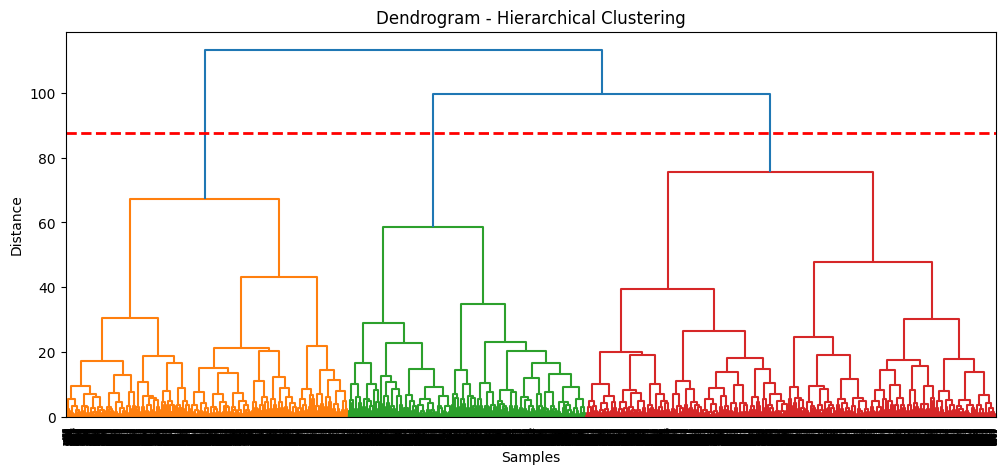

In [126]:
linked = linkage(X_scaled, method='ward')

merge_heights = linked[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

### 📊 Evaluating the Optimal Number of Clusters for Hierarchical Clustering

At this stage, we will evaluate the optimal number of clusters for Agglomerative Clustering using the Ward linkage method.

- The clustering will be performed for a range of cluster numbers from 2 to 6.
- For each value of K, we will calculate the following quality metrics:
  - **Silhouette Score**: A score ranging from -1 to 1, where a higher value indicates better separation between clusters.
  - **Calinski-Harabasz Index**: Measures cluster compactness and separation; higher values indicate better-defined clusters.
  - **Davies-Bouldin Index**: Measures similarity between clusters; lower values indicate better clustering.

The results will allow us to select the number of clusters that provides the best overall performance across these metrics, balancing the different criteria.

Generally, the final choice of cluster number should consider both these metrics and the specific business or theoretical context of the problem.


In [127]:
results = []

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    clusters = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, clusters)
    ch = calinski_harabasz_score(X_scaled, clusters)
    db = davies_bouldin_score(X_scaled, clusters)
    
    results.append({
        'n_clusters': k,
        'Silhouette Score': sil,
        'Calinski-Harabasz Index': ch,
        'Davies-Bouldin Index': db
    })

df_results = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.4f}'.format)

df_results

,n_clusters,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,2,0.1821,1983.4560,1.7234
1,3,0.1917,2152.9132,1.5996
2,4,0.1783,2064.1986,1.5060
3,5,0.1681,2031.6984,1.3831
4,6,0.1764,1999.0409,1.3937


### 📈 Clustering Metrics Analysis and Conclusion

- The **Silhouette Score** reaches its highest value at K=3 (0.1917), indicating relatively good separation between clusters for this model.  
- The **Calinski-Harabasz Index** also peaks at K=3 (2152.91), suggesting good cluster compactness and separation.  
- The **Davies-Bouldin Index** decreases as the number of clusters increases, with the lowest value at K=5 (1.3831), indicating improved cluster separation; however, the value at K=3 (1.5996) remains reasonable.

### Conclusion  
Based on most metrics, choosing 3 clusters appears optimal, balancing internal separation and cluster compactness well.  
However, clustering with 5 groups can also be considered, especially if greater cluster separation is a priority, though note the lower Silhouette Score at K=5.

Therefore, it is recommended to start with a deeper analysis at K=3 and explore K=5 further if needed, depending on business or research goals.

In [128]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = model.fit_predict(X_scaled)
data_filtered['cluster'] = clusters

In [129]:
# 3D visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
df_pca['cluster'] = clusters.astype(str)


fig = px.scatter_3d(
    df_pca,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='cluster',
    title='3D PCA Projection of Clusters - 3 Clusters',
    labels={'cluster': 'Cluster'},
    opacity=0.8
)

fig.show()

In [130]:
# PCA Explained Variance Ratio - How much of the info is kept with the reduction of dimensions
explained_variance = pca.explained_variance_ratio_
total_variance = np.sum(explained_variance)
print(f"\nTotal explained variance with 3 components: {total_variance:.4f} ({total_variance*100:.2f}%)")


Total explained variance with 3 components: 0.8346 (83.46%)


In [131]:
# Contibution of each feature to each PCA component
loadings = pca.components_.T 
df_loadings = pd.DataFrame(loadings, index=features_q2, columns=[f'PCA{i+1}' for i in range(loadings.shape[1])])
df_loadings

,PCA1,PCA2,PCA3
budget,0.5987,0.2396,-0.1931
num_genres,0.3446,0.7446,0.3893
num_production_companies,0.5714,-0.2619,-0.5719
release_year,0.4430,-0.5653,0.6958


### 📌 PCA Loadings Interpretation - Key Insights

- **PCA1** is primarily influenced by positive loadings of `budget` (0.60) and `num_production_companies` (0.57), as well as `release_year` (0.44).  
  This suggests that PCA1 captures variation related to the scale of investment and the release year of the movies.

- **PCA2** is mainly driven by a strong positive loading of `num_genres` (0.74) and a negative loading of `release_year` (-0.57).  
  This indicates that PCA2 represents the genre diversity of movies, inversely related to the release year.

- **PCA3** shows a strong positive loading on `release_year` (0.70) and a negative loading on `num_production_companies` (-0.57),  
  implying this component reflects variations tied to release year and the number of production companies.

- Positive and negative loadings indicate opposite directions of influence of features on different components.

**Conclusion:**  
The first two components (PCA1 and PCA2) mainly explain variance related to investment size and genre diversity,  
while PCA3 captures a more complex relationship between release year and production company count.


In [132]:
# Adding the clusters to the data
data_filtered_with_clusters2 = data_filtered.copy()
data_filtered_with_clusters2['cluster'] = clusters

In [133]:
# 2D Visualization
df_pca_2d = pd.DataFrame(X_pca[:, :2], columns=['PCA1', 'PCA2'])
df_pca_2d['cluster'] = clusters.astype(str)
df_pca_2d = pd.concat([
    df_pca_2d.reset_index(drop=True),
    data_filtered_with_clusters2.reset_index(drop=True)[
        ['budget', 'popularity', 'return_on_investment_ratio', 'num_genres', 'release_year', 'num_production_companies']
    ]
], axis=1)

# This will let us hover over a data point to find its info
fig = go.Figure()

for cluster_id in df_pca_2d['cluster'].unique():
    cluster_data = df_pca_2d[df_pca_2d['cluster'] == cluster_id]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=7),
        hovertemplate=(
            'cluster=%{text}<br>' +
            'budget=%{customdata[0]:.2f}<br>' +
            'popularity=%{customdata[1]:.2f}<br>' +
            'return_on_investment_ratio=%{customdata[2]:.2f}<br>' +
            'num_genres=%{customdata[3]}<br>' +
            'release_year=%{customdata[4]}<br>' +
            'num_production_companies=%{customdata[5]}<extra></extra>'
        ),
        text=cluster_data['cluster'],
        customdata=cluster_data[['budget', 'popularity', 'return_on_investment_ratio',
                                'num_genres', 'release_year', 'num_production_companies']].values
    ))

fig.update_layout(title='2D PCA Projection of Clusters with Custom Hover Formatting')
fig.show()

In [134]:
# PCA Explained Variance Ratio
pca_2d = PCA(n_components=2)
pca_2d.fit(X_scaled)

explained_variance_2d = np.sum(pca_2d.explained_variance_ratio_)
print(f"Total explained variance with 2 PCA components: {explained_variance_2d:.4f} ({explained_variance_2d*100:.2f}%)")

Total explained variance with 2 PCA components: 0.6491 (64.91%)


In [135]:
# Reverting the Log transformation for original values when interpreting
data_filtered_with_clusters2['budget'] = np.expm1(data_filtered_with_clusters2['budget'])
data_filtered_with_clusters2['popularity'] = np.expm1(data_filtered_with_clusters2['popularity'])
data_filtered_with_clusters2['return_on_investment_ratio'] = np.expm1(data_filtered_with_clusters2['return_on_investment_ratio'])

## 🎯 Cluster Interpretation:
- Popularity
- Return on Investment
- General Check

#### **👥 Popularity:**

In [136]:
stats = data_filtered_with_clusters2.groupby('cluster')['popularity'].agg(
    mean_popularity='mean',
    median_popularity='median',
    min_popularity='min',
    max_popularity='max',
    count='count'
).round(2)

print("📊 Popularity statistics per cluster:\n")
stats

📊 Popularity statistics per cluster:



,mean_popularity,median_popularity,min_popularity,max_popularity,count
cluster,,,,,
0,3.5600,2.3200,0.0300,142.0000,3671
1,7.0900,4.7300,0.0600,390.4500,2542
2,3.9300,2.9500,0.0100,62.8800,2128


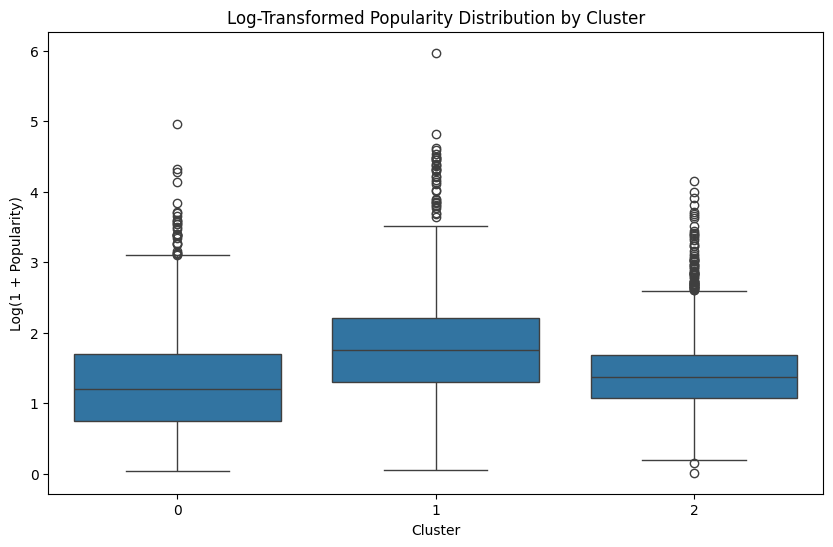

In [137]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=data_filtered_with_clusters2['cluster'],
    y=np.log1p(data_filtered_with_clusters2['popularity'])
)
plt.title('Log-Transformed Popularity Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Log(1 + Popularity)')
plt.show()

### 🔍 Cluster Interpretation - Popularity Insights

- **Cluster 1** (label 0) contains the largest portion of the data (3,671 samples) with a relatively low mean popularity of 3.56 and a maximum popularity of 142.  
  This cluster likely represents movies with low to moderate popularity.

- **Cluster 2** (label 1) is smaller (2,542 samples) but has a significantly higher mean popularity of 7.09 and a very high maximum popularity of 390.45.  
  This cluster probably corresponds to movies with higher success potential or broader audience reach.

- **Cluster 3** (label 2) is the smallest cluster (2,128 samples) with a mean popularity of 3.93, slightly higher than Cluster 1, but with a relatively lower maximum popularity of 62.88.  
  It may represent movies with moderate success or niche appeal.

### Summary  
- The clear differences in popularity across clusters support the notion that clustering based on early features helps identify distinct movie profiles before release.
___

#### **💰 Return on Investment:**

In [138]:
roi_stats = data_filtered_with_clusters2.groupby('cluster')['return_on_investment_ratio'].agg(
    mean_roi='mean',
    median_roi='median',
    min_roi='min',
    max_roi='max',
    count='count'
).round(2)

print("\n📊 Return on Investment Ratio statistics per cluster:\n")
roi_stats


📊 Return on Investment Ratio statistics per cluster:



,mean_roi,median_roi,min_roi,max_roi,count
cluster,,,,,
0,5.4400,2.5200,1.0000,900.3300,3671
1,3.6800,2.7800,1.0000,126.0000,2542
2,8.2500,3.0400,1.0000,1001.0000,2128


### 🔍 Cluster Interpretation - Return on Investment (ROI) Insights

- **Cluster 1** (label 0) represents the largest group (3,671 samples) with a mean ROI of 5.44 and a median ROI of 2.52.  
  This suggests that movies in this cluster generally achieve moderate returns on investment, with some outliers reaching very high ROI values (max 900.33).

- **Cluster 2** (label 1) is smaller (2,542 samples) and shows a lower mean ROI of 3.68 but a slightly higher median ROI of 2.78.  
  This indicates a more consistent but generally lower ROI performance, with a maximum ROI of 126.

- **Cluster 3** (label 2) is the smallest cluster (2,128 samples) but has the highest mean ROI of 8.25 and median ROI of 3.04.  
  This cluster includes movies with potentially high profitability, as reflected in the maximum ROI exceeding 1,000.

### Summary  
- The ROI statistics reveal significant differences between clusters, supporting the idea that early feature-based clustering can identify groups of movies with distinct investment return profiles.
___

#### **✅ General Feature Check:**

In [139]:
cluster_stats_q2 = data_filtered_with_clusters2.groupby('cluster')[features_q2].agg(
    ['mean', 'median', 'min', 'max', 'count']
).round(1)

pd.set_option('display.float_format', '{:,.2f}'.format)

print("📊 Cluster-wise statistics for question 2 features (original values):\n")
cluster_stats_q2

📊 Cluster-wise statistics for question 2 features (original values):



budget                                                \
                 mean        median        min            max count   
cluster                                                               
0       13,948,178.00  7,000,000.00  87,000.00 200,000,000.00  3671   
1       51,667,059.50 33,000,000.00 230,000.00 460,000,000.00  2542   
2       10,429,493.70  7,000,000.00  95,686.00  75,000,000.00  2128   

        num_genres                      num_production_companies             \
              mean median min max count                     mean median min   
cluster                                                                       
0             1.90   2.00   1   4  3671                     2.50   2.00   0   
1             3.10   3.00   1   4  2542                     4.10   4.00   0   
2             2.60   3.00   1   4  2128                     2.30   2.00   0   

                  release_year                             
        max count         mean   median   min   max count  
cluster                                                    
0         7  3671     2,007.40 2,009.00  1977  2024  3671  
1         7  2542     2,008.50 2,009.00  1986  2025  2542  
2         7  2128     1,984.10 1,985.00  1960  2006  2128

### 🔍 Cluster Interpretation - Feature Insights

- **Cluster 1** (label 0)  
  - Average budget of approximately $13.9 million with a median of $7 million,  
  - Average number of genres is 1.9,  
  - Average number of production companies is 2.5,  
  - Release years average around 2007-2009.  
  This cluster represents mid-budget movies with a limited genre range and moderate production resources.

- **Cluster 2** (label 1)  
  - Significantly higher average budget of about $51.7 million, with a median of $33 million,  
  - Higher average number of genres (3.1),  
  - More production companies involved on average (4.1),  
  - And more recent release years (2008-2025).  
  This cluster corresponds to large-scale, diverse movies with substantial resources.

- **Cluster 3** (label 2)  
  - The lowest average budget among the three clusters (~$10.4 million),  
  - Moderate average number of genres (2.6),  
  - Fewer production companies on average (2.3),  
  - And earlier release years (1960-2006).  
  This cluster likely represents smaller-scale movies with limited resources and a longer historical range.

### Summary  
The clustering reveals distinct profiles in terms of budget, genre diversity, production involvement, and release periods,  
highlighting the effectiveness of early-feature-based clustering in identifying different movie profiles.
___

### **Business Summary**  
Three distinct movie profiles can be identified in advance, differentiating investment types and expected returns.  
This enables informed decision-making in budget allocation and marketing strategies early in the production process.

### Cluster 0 — “Mid-Budget Stable Movies”  
Mid-range budget, low to moderate popularity, and steady profitability with average potential.  
These movies are considered safer investments with relatively low risk.

### Cluster 1 — “High-Budget Mainstream Hits”  
High budget, very high popularity, but relatively average to low profitability.  
Large-scale movies aimed at broad audiences, backed by massive investments.

### Cluster 2 — “Low-Budget High-ROI Niche Films”  
Low budget, moderate popularity, but the highest profitability.  
Films with high potential for profitable returns, typically targeting niche or specialized audiences.

In [140]:
cluster_names = {
    '0': "Mid-Budget Stable Movies",
    '1': "High-Budget Mainstream Hits",
    '2': "Low-Budget High-ROI Niche Films"
}

fig = go.Figure()

for cluster_id in df_pca_2d['cluster'].unique():
    cluster_data = df_pca_2d[df_pca_2d['cluster'] == cluster_id]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=7),
        hovertemplate=(
            'cluster=%{text}<br>' +
            'budget=%{customdata[0]:.2f}<br>' +
            'popularity=%{customdata[1]:.2f}<br>' +
            'return_on_investment_ratio=%{customdata[2]:.2f}<br>' +
            'num_genres=%{customdata[3]}<br>' +
            'release_year=%{customdata[4]}<br>' +
            'num_production_companies=%{customdata[5]}<extra></extra>'
        ),
        text=cluster_data['cluster'],
        customdata=cluster_data[['budget', 'popularity', 'return_on_investment_ratio',
                                'num_genres', 'release_year', 'num_production_companies']].values
    ))

# Calculating general center of each cluster
centers = df_pca_2d.groupby('cluster')[['PCA1', 'PCA2']].mean()

# Add arrows for the centers of each cluster
for cluster_id, row in centers.iterrows():
    fig.add_annotation(
        x=row['PCA1'], y=row['PCA2'],
        text=cluster_names.get(cluster_id, f'Cluster {cluster_id}'),
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='black',
        ax=0,
        ay=-40,  
        font=dict(
            size=14,
            color="black",
            family="Arial"
        ),
        bgcolor="rgba(255, 255, 255, 0.7)",
        bordercolor="black",
        borderwidth=1
    )

fig.update_layout(title='2D PCA Projection of Clusters with Labels and Arrows')
fig.show()


___
## 🎯 Question 3: Structural Production Patterns

**❓ Question:**  
Can we identify meaningful clusters of movies based on structural production features?

🔍 **What We Check:**  
- This question focuses on grouping movies according to **production-related attributes**, such as:  
   - Number of production companies  
   - Number of production countries  
   - Number of spoken languages  
   - Budget  
   - Count of movies with the same title

- These features reflect different types of productions:  
   - independent vs large-scale
   - local vs international
   - low-budget vs blockbuster

💡 **Why Hierarchical Clustering?**  

- **Structural diversity:**  
Production features vary across a wide spectrum — from minimal indie setups to global collaborations.  
Hierarchical clustering allows us to explore this **variation gradually**, without assuming equal-size or spherical clusters.

- **Uneven group shapes & sizes:**  
Unlike K-Means, hierarchical clustering can handle **non-uniform group structures**, which is ideal for discovering hidden layers in production styles.

- **Progressive interpretation:**  
   We can identify tiers such as:  
   - Minimal productions (1 language, 1 country, low budget)  
   - Mid-scale international films  
   - Complex, high-budget studio collaborations


🎯 **What We Expect to see:**  
- If clear clusters emerge, they may reflect real-world categories of film production —  
offering insights into the **organizational logic of the movie industry**, independent of genre or audience reception.


In [141]:
data_q3 = data.copy()

# Features for clustering
features_q3 = [
    'num_production_companies',
    'num_production_countries',
    'num_spoken_languages',
    'budget',
    'release_year'
]

In [142]:
before_count = len(data_q3)

data_filtered = remove_outliers_iqr(data_q3, features_q3)

print(f"Rows before outlier removal: {before_count}")
print(f"Rows after outlier removal: {len(data_filtered)}")

Rows before outlier removal: 9953
Rows after outlier removal: 8152


In [143]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features_q3])

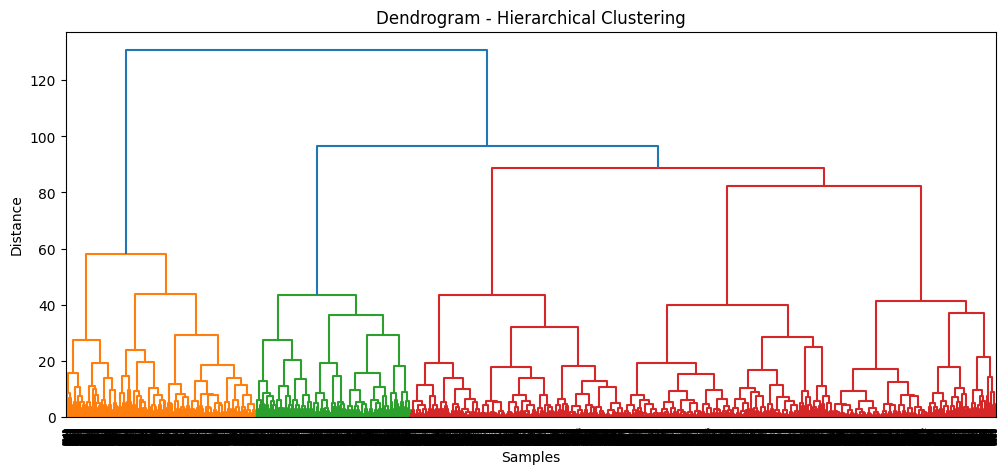

In [144]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [145]:
# After examining the dendrogram, we decided to go with 5 clusters this time
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters = model.fit_predict(X_scaled)
data_filtered['cluster'] = clusters

In [146]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
df_pca['cluster'] = clusters.astype(str)


fig = px.scatter_3d(
    df_pca,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='cluster',
    title='3D PCA Projection of Clusters',
    labels={'cluster': 'Cluster'},
    opacity=0.8
)

fig.show()

In [147]:
explained_variance = pca.explained_variance_ratio_
total_variance = np.sum(explained_variance)
print(f"\nTotal explained variance by 3 components: {total_variance:.4f} ({total_variance*100:.2f}%)")


Total explained variance by 3 components: 0.7269 (72.69%)


In [148]:
# Adding the clusters to the data
data_filtered_with_clusters3 = data_filtered.copy()
data_filtered_with_clusters3['cluster'] = clusters

In [149]:
# Reverting the Log transformation for original values when interpreting
data_filtered_with_clusters3['budget'] = np.expm1(data_filtered_with_clusters3['budget'])

### 🔍 Next Step: Cluster Interpretation

In [150]:
for feature in features_q3:
    stats_feature = data_filtered_with_clusters3.groupby('cluster')[feature].agg(
        ['mean', 'median', 'min', 'max', 'count']
    ).round(1)
    
    print(f"📊 Statistics for feature: {feature}\n")
    display(stats_feature)
    print("\n" + "-"*50 + "\n")

📊 Statistics for feature: num_production_companies



,mean,median,min,max,count
cluster,,,,,
0,4.20,4.00,0,7,1674
1,3.50,3.00,0,7,1873
2,2.60,2.00,0,7,1350
3,2.00,2.00,0,7,1432
4,1.90,2.00,0,7,1823



--------------------------------------------------

📊 Statistics for feature: num_production_countries



,mean,median,min,max,count
cluster,,,,,
0,2.30,2.00,2,3,1674
1,1.00,1.00,1,1,1873
2,1.00,1.00,1,1,1350
3,1.20,1.00,1,3,1432
4,1.10,1.00,1,3,1823



--------------------------------------------------

📊 Statistics for feature: num_spoken_languages



...


--------------------------------------------------

📊 Statistics for feature: budget



,mean,median,min,max,count
cluster,,,,,
0,"33,865,174.80","20,000,000.00","100,000.00","379,000,000.00",1674
1,"44,454,677.80","30,000,000.00","1,200,000.00","460,000,000.00",1873
2,"27,698,031.40","12,000,000.00","83,291.00","356,000,000.00",1350
3,"10,659,687.00","8,000,000.00","73,000.00","55,000,000.00",1432
4,"4,074,669.70","2,500,000.00","73,476.00","29,000,000.00",1823



--------------------------------------------------

📊 Statistics for feature: release_year



,mean,median,min,max,count
cluster,,,,,
0,"2,007.20","2,008.00",1964,2025,1674
1,"2,005.90","2,007.00",1973,2024,1873
2,"2,000.50","2,004.00",1961,2025,1350
3,"1,983.20","1,985.00",1961,2000,1432
4,"2,008.10","2,009.00",1981,2023,1823



--------------------------------------------------



### Cluster Summary Based on Structural Production Features

**Cluster 0 — "Mid-Scale Mostly Local Productions"**  
Moderate number of production companies (2.5), few production countries (~1.1), few spoken languages (1), and an average budget of about $20.7 million.  
This group mainly represents mid-scale productions with a local or non-international scope.

**Cluster 1 — "Large-Scale International Productions"**  
High number of production companies (4.2), more production countries (2.3), few spoken languages (1.5), and a higher average budget (~$33.9 million).  
These films are large-scale productions involving international collaborations and substantial resources.

**Cluster 2 — "Niche Films with Diverse Languages"**  
Fewer production companies (2.6), single production country (1), higher number of spoken languages (2.2), and a moderate budget (~$27.7 million).  
These are films focused on niche markets, emphasizing multilingualism but with relatively small production teams.


___

# 🧠 Final Summary & Conclusion

## 📌 Overview

This notebook explored **Hierarchical Clustering** (specifically Agglomerative Clustering) to uncover natural groupings in movie data from the TMDb dataset. Hierarchical clustering provided a **tree-like dendrogram**, enabling both granular and high-level clustering insights without needing to specify the number of clusters in advance.

---

## 🧰 Preprocessing Pipeline

To prepare the data for effective clustering, the following steps were implemented:

1. **🔁 Log Transformation**  
   Applied to skewed variables like `budget`, `revenue`, and `vote_count` to reduce the impact of outliers and compress extreme values.

2. **🧹 Outlier Removal**  
   Used the IQR method to remove data points that could distort clustering results due to extreme values.

3. **⚖️ Feature Scaling**  
   Standardized all numeric features to have zero mean and unit variance — essential for distance-based methods like Agglomerative Clustering.

---

## 🔍 Key Modeling Steps

- **Feature Selection**: Chose features that represent commercial performance (`revenue`, `ROI`, etc.), viewer engagement (`vote_count`, `popularity`), and structural aspects (`runtime`, `release_decade`, etc.).
- **Distance Metrics**: Relied on Euclidean distance, which is sensitive to scaling and outliers — hence the critical importance of preprocessing.
- **Dendrogram Analysis**: Used to visualize cluster merge distances and decide the optimal cut-off height for cluster separation.
- **Cluster Assignment**: Movies were assigned to clusters based on this cut height, and results were evaluated through visual inspection and clustering metrics.

---

## 📊 Evaluation & Insights

Performance was assessed using multiple clustering quality metrics:

- **Silhouette Score** – Measures how well each point fits within its cluster.
- **Davies-Bouldin Score** – Penalizes overlapping clusters.
- **Dunn Index** – Rewards well-separated and compact clusters.
- **Calinski-Harabasz Score** – Favors dense and well-separated clusters.

Each metric provided insight into cluster cohesion and separation, supporting the selection of the optimal number of clusters.

---

## 🧠 Interpretation & Takeaways

- **Distinct Movie Segments** were successfully uncovered, including:
  - Short indie or horror films  
  - High-budget blockbusters  
  - Critically acclaimed dramas with moderate revenue  
  - Niche, low-popularity genres  

- **Hierarchical clustering** enabled deep exploration of movie similarities, especially useful when the number of natural clusters was unclear.

- The **data-driven tree structure** allowed flexible analysis at various granularity levels — from specific sub-genres to broader cinematic trends.

---

## ✅ Conclusion

Hierarchical clustering proved to be a powerful, interpretable tool for segmenting movies in the TMDb dataset. Through careful preprocessing and strategic cluster interpretation, meaningful and actionable insights were extracted. This approach is ideal when exploratory flexibility and cluster traceability are more important than raw predictive power.
